In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import nltk
nltk.download('stopwords')

import re

from nltk.corpus import stopwords

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [2]:
uploaded = files.upload()

NameError: name 'files' is not defined

In [3]:
from google.colab import files

In [4]:
uploaded = files.upload()

Saving Twitter_Data.csv.zip to Twitter_Data.csv.zip


In [5]:
import zipfile

with zipfile.ZipFile("Twitter_Data.zip", "r") as zip_ref:
    zip_ref.extractall()

FileNotFoundError: [Errno 2] No such file or directory: 'Twitter_Data.zip'

In [6]:
import os

print(os.listdir())

['.config', 'Twitter_Data.csv.zip', 'sample_data']


In [7]:
import os

for file in os.listdir():
    print(file)

.config
Twitter_Data.csv.zip
sample_data


In [8]:
import zipfile

with zipfile.ZipFile("Twitter_Data.csv.zip", "r") as zip_ref:
    zip_ref.extractall()

print("Dataset Extracted Successfully!")

Dataset Extracted Successfully!


In [9]:
import os

print(os.listdir())

['.config', 'Twitter_Data.csv.zip', 'Twitter_Data.csv', 'sample_data']


In [10]:
df = pd.read_csv("Twitter_Data.csv")

df.head()

,clean_text,category
0,when modi promised “minimum government maximum...,-1.0
1,talk all the nonsense and continue all the dra...,0.0
2,what did just say vote for modi welcome bjp t...,1.0
3,asking his supporters prefix chowkidar their n...,1.0
4,answer who among these the most powerful world...,1.0


In [11]:
print("Shape of Dataset:", df.shape)

Shape of Dataset: (162980, 2)


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 162980 entries, 0 to 162979
Data columns (total 2 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   clean_text  162976 non-null  object 
 1   category    162973 non-null  float64
dtypes: float64(1), object(1)
memory usage: 2.5+ MB


In [13]:
df.isnull().sum()

,0
clean_text,4
category,7


In [14]:
df = df.dropna()

print(df.isnull().sum())

clean_text    0
category      0
dtype: int64


In [15]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [16]:
df = df.drop_duplicates()

print(df.shape)

(162969, 2)


In [17]:
df['category'].value_counts()

,count
category,
1.0,72249
0.0,55211
-1.0,35509


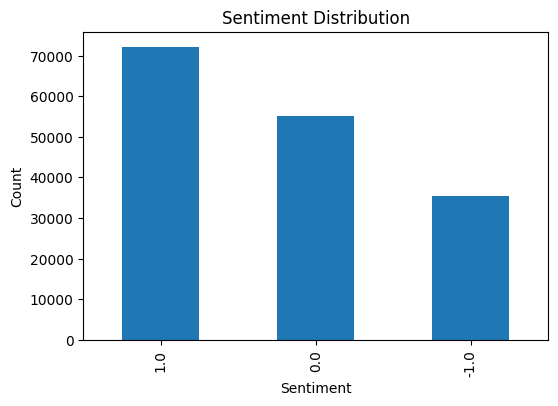

In [18]:
plt.figure(figsize=(6,4))
df['category'].value_counts().plot(kind='bar')

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")

plt.show()

In [19]:
df['category'] = df['category'].replace({
    -1: 'Negative',
     0: 'Neutral',
     1: 'Positive'
})

df.head()

,clean_text,category
0,when modi promised “minimum government maximum...,Negative
1,talk all the nonsense and continue all the dra...,Neutral
2,what did just say vote for modi welcome bjp t...,Positive
3,asking his supporters prefix chowkidar their n...,Positive
4,answer who among these the most powerful world...,Positive


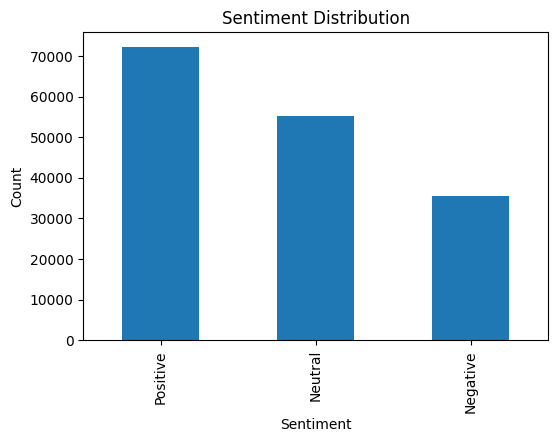

In [20]:
plt.figure(figsize=(6,4))
df['category'].value_counts().plot(kind='bar')

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")

plt.show()

In [21]:
X = df['clean_text']
y = df['category']

In [22]:
vectorizer = TfidfVectorizer(stop_words='english')

X = vectorizer.fit_transform(X.astype(str))

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [24]:
model = MultinomialNB()

model.fit(X_train, y_train)

MultinomialNB()

In [25]:
y_pred = model.predict(X_test)

In [26]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.5738786279683378


In [27]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    Negative       0.92      0.13      0.23      7152
     Neutral       0.84      0.34      0.49     11067
    Positive       0.52      0.97      0.67     14375

    accuracy                           0.57     32594
   macro avg       0.76      0.48      0.47     32594
weighted avg       0.72      0.57      0.51     32594



In [28]:
print(confusion_matrix(y_test, y_pred))

[[  957   309  5886]
 [   33  3815  7219]
 [   46   396 13933]]


In [29]:
sample = ["This phone is absolutely amazing. I love it!"]

sample_vector = vectorizer.transform(sample)

prediction = model.predict(sample_vector)

print("Predicted Sentiment:", prediction[0])

Predicted Sentiment: Positive


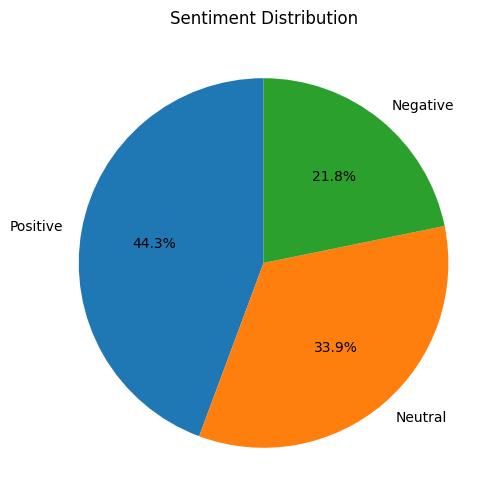

In [31]:
plt.figure(figsize=(6,6))
df['category'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Sentiment Distribution")
plt.ylabel("")
plt.show()

In [32]:
sample = ["This phone is amazing. I love using it."]

sample_vector = vectorizer.transform(sample)

prediction = model.predict(sample_vector)

print("Predicted Sentiment:", prediction[0])

Predicted Sentiment: Positive


In [33]:
sample = ["Worst experience ever. Totally disappointed."]

sample_vector = vectorizer.transform(sample)

prediction = model.predict(sample_vector)

print("Predicted Sentiment:", prediction[0])

Predicted Sentiment: Negative


In [34]:
sample = ["The product is okay, nothing special."]

sample_vector = vectorizer.transform(sample)

prediction = model.predict(sample_vector)

print("Predicted Sentiment:", prediction[0])

Predicted Sentiment: Positive


In [35]:
print("Accuracy:", accuracy)

Accuracy: 0.5738786279683378


In [36]:
!pip install wordcloud

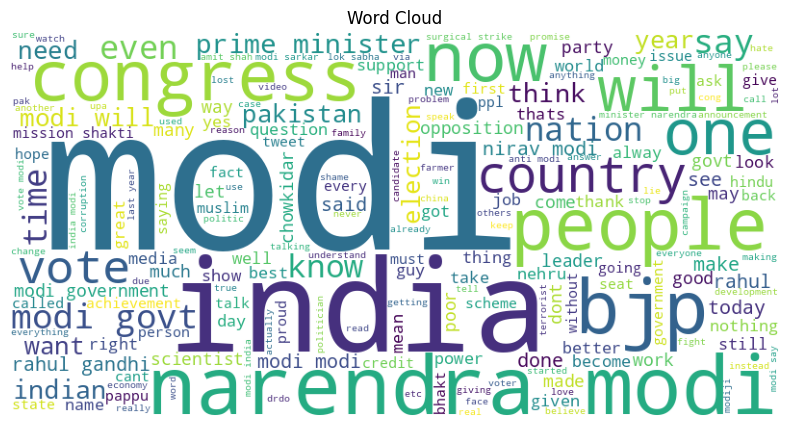

In [37]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

text = " ".join(df['clean_text'].astype(str))

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Word Cloud")
plt.show()

In [ ]:
while True:
    text = input("Enter a tweet (type 'exit' to stop): ")

    if text.lower() == "exit":
        break

    vector = vectorizer.transform([text])

    prediction = model.predict(vector)

    print("Predicted Sentiment:", prediction[0])

Enter a tweet (type 'exit' to stop): i love this phone
Predicted Sentiment: Positive
